# Decision Tree Regressor

In [2]:
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()

#Creating feature and target arrays
X, y = california.data, california.target
columns = california.feature_names

import pandas as pd

df_california = pd.DataFrame(X,columns=california.feature_names)
df_california['target'] = y

In [3]:
#Predicting house value from a single feature
#X_lstat = df_boston[['LSTAT']]
#y = df_boston[['target']]

In [4]:
from sklearn.model_selection import train_test_split

X=X[y<50]
y=y[y<50]

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3,
                                                    random_state=42)

#DEFINE YOUR REGRESSOR and THE PARAMETERS GRID
from sklearn.tree import DecisionTreeRegressor
import numpy as np

regressor = DecisionTreeRegressor()
parameters = {"max_depth":[3,5,7],
              "min_samples_leaf": [10,20,30]}

#DEFINE YOUR GRIDSEARCH
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(regressor, parameters, cv=3, scoring ='neg_mean_absolute_error')
gs = gs.fit(X_train,y_train)

#summarize the results of your GRIDSEARCH
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))
means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

#Returns the coefficient of determination R^2 of the prediction.
#Explained variance score: 1 is perfect prediction
gs.score(X_test, y_test)

***GRIDSEARCH RESULTS***
Best score: -0.472227 using {'max_depth': 7, 'min_samples_leaf': 10}
-0.595287 (0.002350) with: {'max_depth': 3, 'min_samples_leaf': 10}
-0.595287 (0.002350) with: {'max_depth': 3, 'min_samples_leaf': 20}
-0.595287 (0.002350) with: {'max_depth': 3, 'min_samples_leaf': 30}
-0.526118 (0.007598) with: {'max_depth': 5, 'min_samples_leaf': 10}
-0.525976 (0.007661) with: {'max_depth': 5, 'min_samples_leaf': 20}
-0.524614 (0.009610) with: {'max_depth': 5, 'min_samples_leaf': 30}
-0.472227 (0.021790) with: {'max_depth': 7, 'min_samples_leaf': 10}
-0.472497 (0.020371) with: {'max_depth': 7, 'min_samples_leaf': 20}
-0.473044 (0.018592) with: {'max_depth': 7, 'min_samples_leaf': 30}


-0.4721916750695978

## Cross Validation

La validación cruzada es fundamental cuando se trabaja con modelos como el Decision Tree Regressor por varias razones:

Evaluación Robusta del Modelo: Ayuda a obtener una estimación más fiable del rendimiento del modelo en datos no vistos, reduciendo el riesgo de que la métrica de evaluación (como el error cuadrático medio o el MAE) sea optimista o pesimista debido a una división de datos particular.

Detección de Sobreajuste (Overfitting): Los árboles de decisión son propensos al sobreajuste, lo que significa que pueden memorizar los datos de entrenamiento y no generalizar bien a nuevos datos. La validación cruzada ayuda a identificar si el modelo está sobreajustando al evaluar su rendimiento en diferentes subconjuntos de datos.

Optimización de Hiperparámetros: Es crucial para la selección de los mejores hiperparámetros del modelo (como max_depth o min_samples_leaf que has utilizado) sin sobreajustar al conjunto de entrenamiento. La búsqueda en cuadrícula (GridSearchCV) o la búsqueda aleatoria (RandomizedSearchCV) utilizan la validación cruzada internamente para encontrar la mejor combinación de parámetros.

In [10]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Get the best estimator from the GridSearchCV
best_tree_model = gs.best_estimator_

# Perform cross-validation with 5 folds on the best model
cv_scores = cross_val_score(best_tree_model, X, y, cv=5, scoring='neg_mean_absolute_error')

print("Cross-validation scores (Negative MAE for each fold):")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score:.4f}")

print(f"\nMean Cross-validation score (Negative MAE): {np.mean(cv_scores):.4f}")
print(f"Standard Deviation of Cross-validation scores: {np.std(cv_scores):.4f}")

Cross-validation scores (Negative MAE for each fold):
  Fold 1: -0.6120
  Fold 2: -0.5124
  Fold 3: -0.5388
  Fold 4: -0.5849
  Fold 5: -0.5506

Mean Cross-validation score (Negative MAE): -0.5597
Standard Deviation of Cross-validation scores: 0.0350


In [5]:
error_train=gs.predict(X_train)-y_train
error_test=gs.predict(X_test)-y_test
pd.DataFrame(error_train).describe()

,0
count,1.444800e+04
mean,-2.975349e-16
std,6.228639e-01
min,-3.959797e+00
25%,-2.631546e-01
50%,5.980629e-02
75%,3.519495e-01
max,3.027852e+00


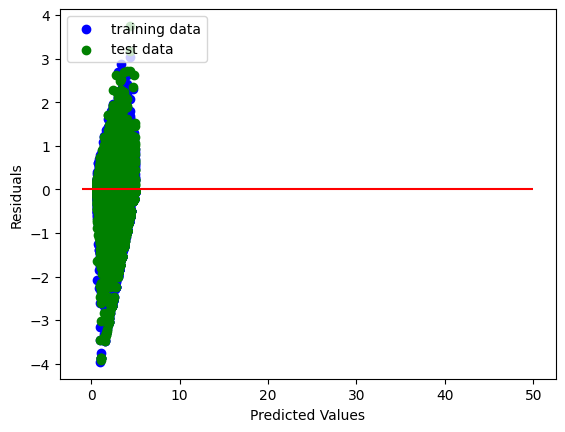

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.scatter(gs.predict(X_train),error_train, c="b", label="training data")
plt.scatter(gs.predict(X_test),error_test, c="g", label="test data")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.legend(loc="upper left")
plt.hlines(y=0, xmin=-1, xmax=50, color="r")
plt.show()

In [7]:
from sklearn import metrics

print("MAE train: ", metrics.mean_absolute_error(y_train, gs.predict(X_train)))
print("MSE train: ",metrics.mean_squared_error(y_train, gs.predict(X_train)))
print("RMSE train: ",np.sqrt(metrics.mean_squared_error(y_train, gs.predict(X_train))))
print("r2: ",np.sqrt(metrics.r2_score(y_train, gs.predict(X_train))))

print("MAE test: ", metrics.mean_absolute_error(y_test, gs.predict(X_test)))
print("MSE test: ",metrics.mean_squared_error(y_test, gs.predict(X_test)))
print("RMSE test: ",np.sqrt(metrics.mean_squared_error(y_test, gs.predict(X_test))))
print("r2: ",np.sqrt(metrics.r2_score(y_test, gs.predict(X_test))))

MAE train:  0.4425502896441597
MSE train:  0.3879325494127908
RMSE train:  0.6228423150467467
r2:  0.8428715202430253
MAE test:  0.4721916750695978
MSE test:  0.4504927410554472
RMSE test:  0.6711875602657182
r2:  0.8104183633662911


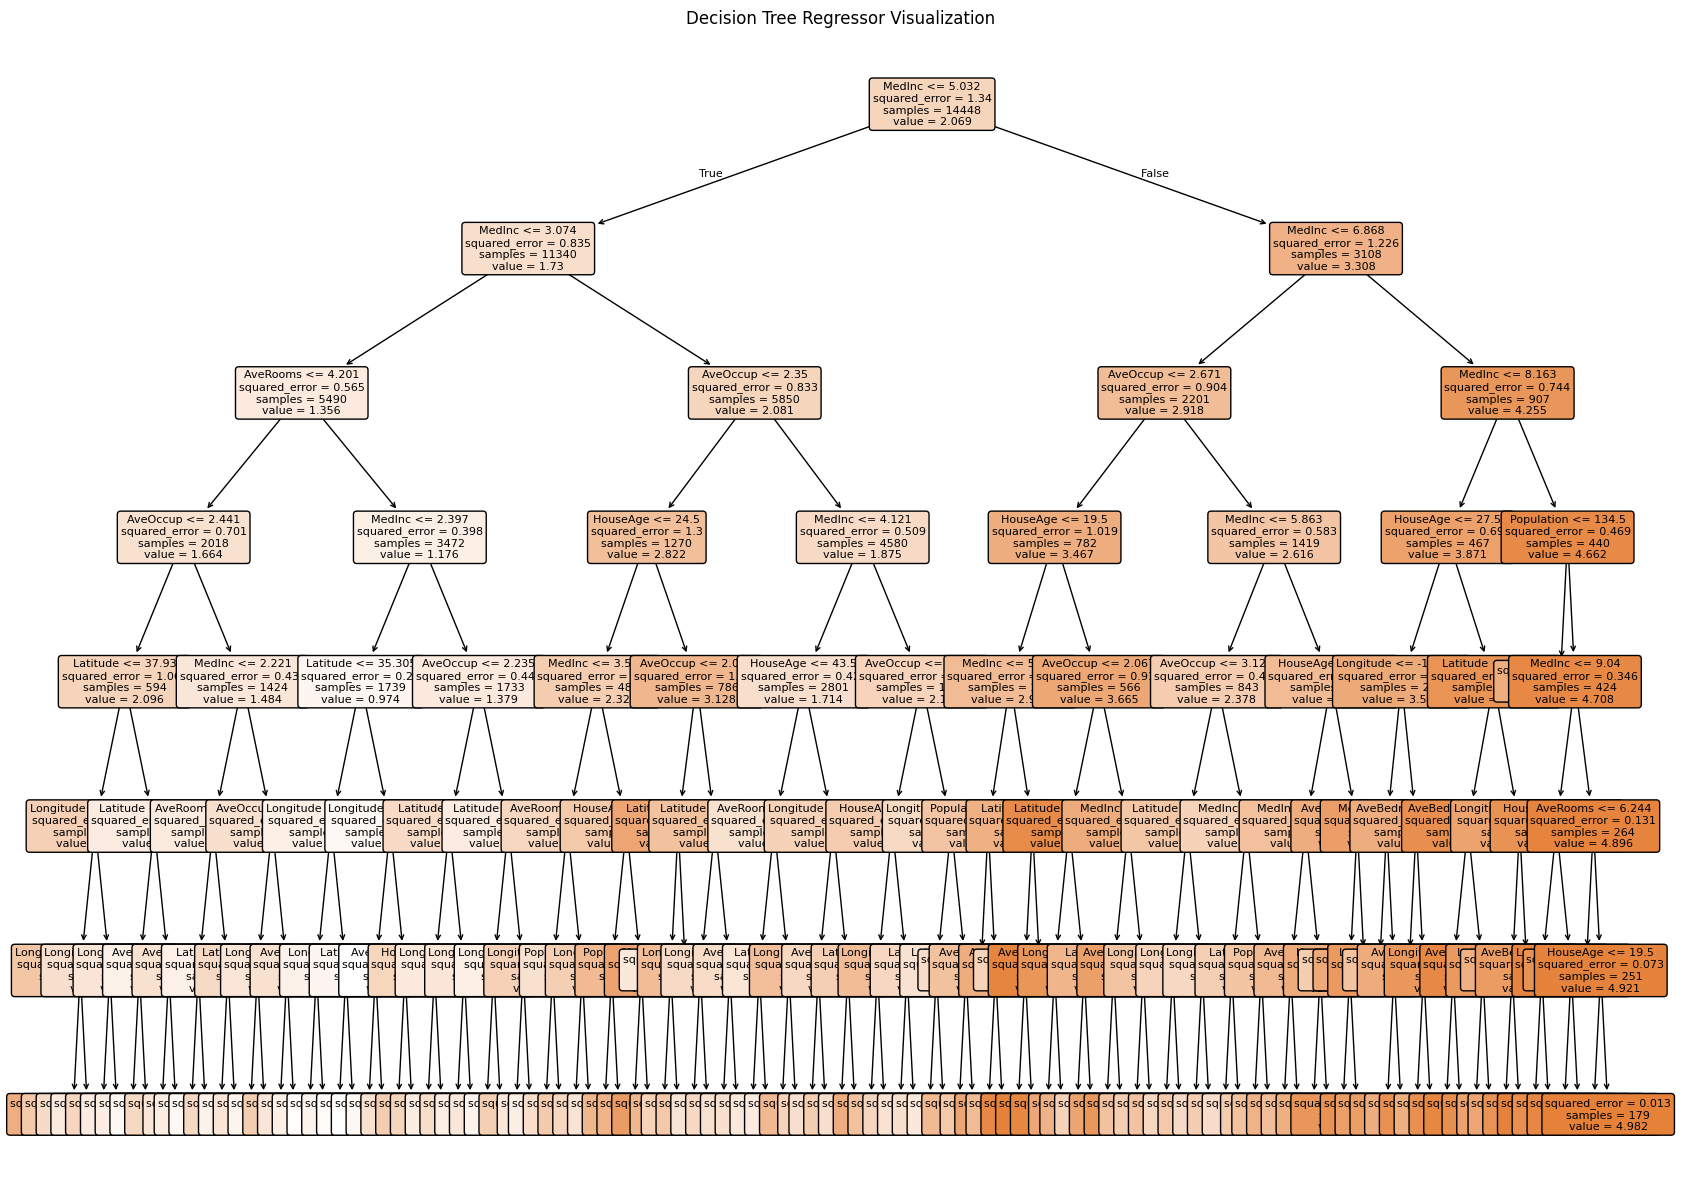

In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Get the best estimator from the GridSearchCV
best_tree_model = gs.best_estimator_

# Set a larger figure size for better visualization
plt.figure(figsize=(20,15))

# Plot the decision tree
plot_tree(best_tree_model,
          filled=True,
          feature_names=california.feature_names,
          rounded=True,
          fontsize=8)

plt.title("Decision Tree Regressor Visualization")
plt.show()